# Лекция 1. Основные понятия и задачи ML. Линейные методы классификации и регрессии. Вероятностная постановка задачи.

## Введение

Материалцы лекциии основаны на конспектах лекций Мокаева Т. Н., Бухваловой В. В.

![](img/img01.jpg)

Рис. 1. Пересечение технологий: от искусственного интеллекта к глубокому обучению через машинное обучение и нейросети

![](img/img02.jpg)

Рис. 2. Представление того, как разные разделы математики формируют методы и задачи машинного обучения

## Основные понятия

- $X$ — входные данные (множество объектов)  
- $X' = x_1, \dots, x_l \subset X$ — объекты, входные данные (training sample)  
- $Y' = y_1, \dots, y_l \subset Y$ — выходные данные (ответы)  
- $(X', Y')$ — обучающая выборка  

## Задача машинного обучения

По обучающей выборке $x_1, \dots, x_l$ и известным ответам $y_1, \dots, y_l$ найти функцию  
$a : X \to Y$, приближающую неизвестную функцию $y$ на всем множестве $X$.

## Пример. Интерполяция

- $X = \mathbb{R}, \; Y = \mathbb{R}$  
- Дано: $(x_1, f(x_1)), (x_2, f(x_2)), \dots, (x_l, f(x_l))$  
- Задача: найти полином $P_l$, такой что $P_l(x_i) = f(x_i), \; i \in \{1, \dots, l\}$  

## Задача

Выписать полином $P_l$ в явном виде.

## Задача

Написать программу на Python, позволяющую по входным парам $(x_i, y_i)$  
задать функцию, принимающую значения $y_i$ в точках $x_i$.

## Признаковое описание объектов

### Признаки

- $f_j : X \to D_j,\; j \in \{1, \dots, n\}$ — признаки объектов (features)  
- $(f_1(x), \dots, f_n(x))$ — признаковое описание объекта (feature data)  

### Типы признаков

- **Бинарный**: $D_j = \{0, 1\}$  
- **Номинальный**: $|D_j| < \infty$  
- **Порядковый**: $|D_j| < \infty,\; D_j$ упорядочено  
- **Количественный**: $D_j = \mathbb{R}$  

### Пример

$X$ — входящие запросы для интернет-магазина:

- Спам / не спам  
- Тип запроса — покупка, возврат, логин, поиск товара, клик по рекламе  
- Возраст пользователя  
- Сумма товаров в корзине  

## Задачи машинного обучения

### Задача классификации (classification)

- $Y = \{0, 1\}$ — бинарная классификация  
- $Y = \{1, \dots, M\}$ — на $M$ непересекающихся классов  
- $Y = \{0, 1\}^M$ — на пересекающиеся классы  

Примеры:
- Видеопоток камеры автопилота автомобиля — текущее ограничение скорости  
- Поисковый запрос — запрос картинки, запрос из Wiki, арифметическая операция, ...  

### Задача восстановления регрессии

- $Y = \mathbb{R}^m$ (Regression)  

Пример:
- Определение линейного тренда цены на товар (скорость роста)  

### Задача ранжирования

- $|Y| < \infty$ (ranking, learning to rank)  

Пример:
- Поисковая выдача  

### Задача обучения без учителя

- (unsupervised learning)  

Примеры:
- Игра в Go, автопилот, Reinforcement learning  

## Предсказывающая модель

Модель (predictive model) — параметрическое семейство функций:

$$
A = \{ g(x, \theta) \mid \theta \in \Theta \}
$$

где $g : X \times \Theta \to Y$ — фиксированная функция, $\theta$ — параметр.

### Пример

Линейное приближение с параметрами $\theta_1, \theta_2, \dots, \theta_n \in \mathbb{R}^n$.

#### Задача регрессии (по признакам)

$$
g(x, \theta) = \sum_{i=1}^{n} \theta_i f_i(x)
$$

#### Задача классификации (по признакам)

$$
g(x, \theta) = \operatorname{sign} \left( \sum_{i=1}^{n} \theta_i f_i(x) \right)
$$

## Задача

По данным из `Housing.csv` построить линейную модель предсказания цены.

In [6]:
import pandas as pd

# Читаем файл (укажи свой путь к файлу)
df = pd.read_csv("files/Housing.csv")

# Выводим первые 10 строк
print(df.head(10))

   Unnamed: 0    price  lotsize  bedrooms  bathrms  stories driveway recroom  \
0           1  42000.0     5850         3        1        2      yes      no   
1           2  38500.0     4000         2        1        1      yes      no   
2           3  49500.0     3060         3        1        1      yes      no   
3           4  60500.0     6650         3        1        2      yes     yes   
4           5  61000.0     6360         2        1        1      yes      no   
5           6  66000.0     4160         3        1        1      yes     yes   
6           7  66000.0     3880         3        2        2      yes      no   
7           8  69000.0     4160         3        1        3      yes      no   
8           9  83800.0     4800         3        1        1      yes     yes   
9          10  88500.0     5500         3        2        4      yes     yes   

  fullbase gashw airco  garagepl prefarea  
0      yes    no    no         1       no  
1       no    no    no         

## Решение

![](img/img03.png)

## Генерация признаков

- $X = Y = \mathbb{R}$  

- $Y = x + \sin(x) + \text{шум}$  

- 3 признака:  
  - $\{x, x^2, 1\}$  
  - $\{x, \sin(x), 1\}$  

![](img/img04.png)

## Обучение

### Этап обучения (train)

Метод обучения (подбор параметров $\theta$, learning algorithm):

$$
\mu : (X \times Y)' \to A
$$

По выборке $X' = (x_i, y_i)_{i=1}^{l}$ строится алгоритм (подбираются параметры $\theta$):

$$
a = \mu(X'):
\left[
\begin{pmatrix}
f_1(x_1) & \dots & f_n(x_1) \\
\vdots & \ddots & \vdots \\
f_1(x_l) & \dots & f_n(x_l)
\end{pmatrix},
\begin{pmatrix}
y_1 \\
\vdots \\
y_l
\end{pmatrix}
\right] \to a
$$

### Этап проверки (применения, тестирования, test)

Для новых объектов $x_k^t$ применяется функция $a$:

$$
\begin{pmatrix}
f_1(x_1^t) & \dots & f_n(x_1^t) \\
\vdots & \ddots & \vdots \\
f_1(x_k^t) & \dots & f_n(x_k^t)
\end{pmatrix}
\to
\begin{pmatrix}
a(x_1^t) \\
\vdots \\
a(x_k^t)
\end{pmatrix}
$$

## Функционал качества (потерь, loss function)

$L(a, x)$ — величина ошибки алгоритма $a$ на объекте $x$.

### Задачи классификации

$$
L(a, x) = [a(x) \ne y(x)] =
\begin{cases}
1, & a(x) \ne y(x), \\
0, & a(x) = y(x)
\end{cases}
$$

### Задачи регрессии

$$
L(a, x) = (a(x) - y(x))^2 \quad (||\cdot||_2 \text{ метрика})
$$

Реже другие метрики:

$$
L(a, x) = |a(x) - y(x)| \quad (||\cdot||_1 \text{ метрика})
$$

$$
L(a, x) = (a(x) - y(x))^2 + (a'(x) - y'(x))^2
$$

### Эмпирический риск

$Q(a, X')$ — алгоритма $a$ на всем множестве $X'$:

$$
Q(a, X') = \sum_{i=1}^{l} L(a, x_i)
$$

$$
Q(a, X') = \frac{1}{l} \sum_{i=1}^{l} L(a, x_i)
$$

### Задача минимизации эмпирического риска

$$
\mu(X') = \arg\min_{a \in A} Q(a, X')
$$

## Задача линейной регрессии

### Пространство ответов

$$
Y = \mathbb{R}
$$

### Числовые признаки

$$
f_j : X \to \mathbb{R}, \quad j = 1, 2, \dots, n
$$

### Линейная регрессия

$$
g(x, \theta) = \sum_{j=1}^{n} \theta_j f_j(x)
$$

### Функция потерь

$$
L(g(x, \theta), x) = (g(x, \theta) - y(x))^2
$$

### Эмпирический риск

$$
Q(a, X') = \frac{1}{l} \sum_{i=1}^{l} (g(x_i, \theta) - y(x_i))^2
$$

### Задача оптимизации (метод наименьших квадратов)

$$
\mu(X') = \arg\min_{\theta} \frac{1}{l} \sum_{i=1}^{l} (g(x_i, \theta) - y(x_i))^2
$$

![](img/img05.png)

## Задача

Аппроксимировать функцию
$$
y(x) = \frac{1}{1 + 25x^2}
$$
полиномами разной степени на $[-2, 2]$.

### Признаки

$$
f_j(x) = x^j, \quad j = 0, 1, \dots, n
$$

### Регрессия

$$
g(x, \theta) = \sum_{j=0}^{n} \theta_j x^j
$$

### Функция потерь

$$
L(g(x, \theta), x) = (g(x, \theta) - y(x))^2
$$

### Задача оптимизации (метод наименьших квадратов)

$$
\mu(X') = \arg\min_{\theta} \frac{1}{l} \sum_{i=1}^{l} (g(x_i, \theta) - y(x_i))^2
$$

### Обучающая выборка

$$
X' = \left\{ x_i = 4 \cdot \frac{i - 1}{l - 1} - 2 \;\middle|\; i = 1, 2, \dots, l \right\}
$$

### Тестовая (проверочная, контрольная) выборка

$$
X^{t} = \left\{ x_i = 4 \cdot \frac{i - 0.5}{l - 1} - 2 \;\middle|\; i = 1, 2, \dots, l - 1 \right\}
$$

Построить графики для степеней полинома:
$$
n = 0, 1, 10, 40
$$

Количество значений в выборке:
$$
l = 50
$$

## Решение

### Эмпирический риск

$$
Q(a, X') = \frac{1}{l} \sum_{i=1}^{l} \left| g(x_i, \theta) - y(x_i) \right|
$$

в зависимости от количества степеней полинома $n$.

![](img/img06.png)

## Подходы к проблеме переобучения

### Hold-out

Разделение данных $X$ на два подмножества: train $X^{l}$ и test $X^{k}$.

$$
HO(\mu, X^{l}, X^{k}) = Q(\mu(X^{l}), X^{k}) \to \min
$$

> качество зависит от разбиения

---

### Скользящий контроль (Leave-one-out)

Обучение на всех данных, кроме одного значения, и усреднение по результатам:

$$
LOO(\mu, X^{l}) = \frac{1}{l} \sum_{i=1}^{l} Q(\mu(X^{l} \setminus x_i), x_i) \to \min
$$

> долгий процесс обучения

---

### Кросс-проверка (Cross-validation)

Обучение по $N$ разбиениям $X$ на два подмножества: train $X_n^{l}$ и test $X_n^{k}$.

$$
CV(\mu, X^{l}) = \frac{1}{N} \sum_{n} Q(\mu(X_n^{l}), X_n^{k}) \to \min
$$

---

### Вероятностный подход

Учитываем только разбиения, меняющие оценку больше чем на $\varepsilon$:

$$
Q_{\varepsilon}(\mu, X^{l}) = \frac{1}{N} \sum_{n} 
\left[ Q(\mu(X_n^{l}), X_n^{k}) - Q(\mu(X_n^{l}), X_n^{l}) \ge \varepsilon \right] \to \min
$$

# Вероятностный подход

## Принцип максимума правдоподобия

- $X, Y$ — вероятностные пространства с совместной плотностью  
$$
p(x, y \mid \omega) = p(y \mid x, \omega)\, p(x)
$$

- $p(y \mid x, \omega)$ — апостериорная плотность вероятности  

- $X'$ — независимые одинаково распределённые случайные величины (i.i.d.)  

- $(x_i, y_i)_{i=1}^{l} \sim p(x, y \mid \omega)$ — плотность распределения для выборки  

### Оценка максимума правдоподобия

Задача — подобрать $\omega$, так что вероятность появления пары $(x_i, y_i)$ максимальна:

$$
\prod_{i=1}^{l} p(x_i, y_i \mid \omega) \to \max_{\omega}
$$

$$
\prod_{i=1}^{l} p(y_i \mid x_i, \omega)\, p(x_i) \to \max_{\omega}
$$

### Логарифм правдоподобия

$$
L(\omega) = \sum_{i=1}^{l} \log p(y_i \mid x_i, \omega) \to \max_{\omega}
$$

### Пример: бинарная классификация

$$
\pi(x, \omega) = P(y = 1 \mid x, \omega)
$$

$$
L(\omega) = \sum_{i=1}^{l} \left[
y_i \log \pi(x_i, \omega) + (1 - y_i)\log(1 - \pi(x_i, \omega))
\right] \to \max_{\omega}
$$

## Связь правдоподобия и эмпирического риска

- $X, Y$ — вероятностные пространства с совместной плотностью  
$$
p(x, y \mid \omega) = p(y \mid x, \omega)\, p(x)
$$

- $X'$ — независимые одинаково распределённые случайные величины (i.i.d.)  

- $(x_i, y_i)_{i=1}^{l} \sim p(x, y \mid \omega)$ — распределение выборки  

---

### Логарифм правдоподобия

$$
L(\omega) = \sum_{i=1}^{l} \log p(y_i \mid x_i, \omega) \to \max_{\omega}
$$

---

### Минимизация эмпирического риска

$$
Q(\omega) = \sum_{i=1}^{l} L(y_i, g(x_i, \omega)) \to \min_{\omega}
$$

---

### Эквивалентность

Пусть

$$
L(y_i, g(x_i, \omega)) = -\log p(y_i \mid x_i, \omega)
$$

тогда задачи максимизации правдоподобия и минимизации эмпирического риска совпадают.

## Стохастическая природа параметров

- $P(y \mid x, \omega)$ — вероятностная модель данных  

Будем считать, что параметры $\omega$ также имеют вероятностное распределение.  
Тогда можно задать ограничения на пространство параметров с помощью плотности распределения $p(\omega)$.

$$
p(\omega) = p(\omega; \gamma)
$$

— априорное распределение параметров, где $\gamma$ — гиперпараметры.

---

### Совместное распределение данных и параметров

$$
p(X', \omega) = p(X' \mid \omega; \gamma)\, p(\omega; \gamma)
$$

Далее предположим, что $X'$ и $\omega$ независимы и $P(x_i) = 1$, тогда:

$$
p(X', \omega) = p(\omega; \gamma)
$$

---

### Принцип максимума апостериорной вероятности (MAP)

$$
\prod_{i=1}^{l} p(y_i \mid x_i, \omega)\, p(x_i, \omega) \to \max_{\omega}
$$

$$
\prod_{i=1}^{l} p(y_i \mid x_i, \omega)\, p(\omega; \gamma) \to \max_{\omega}
$$

$$
L(\omega) = \sum_{i=1}^{l} \log p(y_i \mid x_i, \omega) + \log p(\omega; \gamma) \to \max_{\omega}
$$

Таким образом, $\log p(\omega; \gamma)$ выступает в роли регуляризатора.

Желательно, чтобы параметры $\omega$ были независимы, симметричны относительно $0$ и небольшие по модулю.

## Пример: нормальное распределение (Гаусса)

Плотность $n$-мерного нормального распределения:

$$
p(\omega, C) = \frac{1}{(2\pi C)^{n/2}} \exp\left(-\frac{\|\omega\|^2}{2C}\right),
\quad
\|\omega\|^2 = \sum_{j=1}^{n} \omega_j^2
$$

### Регуляризатор

$$
L(\omega) = -\log(p(\omega, C)) = \frac{1}{2C} \|\omega\|^2 + \text{const}
$$

### Задача

$$
\sum_{i=1}^{l} \log(p(y_i \mid x_i, \omega)) + \frac{1}{2C} \sum_{j=1}^{n} \omega_j^2 + \text{const}
\to \max_{\omega}
$$

Заметим, что в этом случае регуляризатор совпадает с ранее рассмотренным $L_2$ регуляризатором с параметром
$$
\tau = \frac{1}{C}
$$

Желательно, чтобы параметры $\omega$ были независимы, симметричны относительно $0$ и небольшие по модулю.

## Пример: распределение Лапласа

Плотность распределения Лапласа:

$$
p(\omega, \mu, \beta) = \frac{1}{(2\beta)^n} \exp\left(-\frac{\|\omega - \mu\|}{\beta}\right),
$$

где

$$
\|\omega\| = \sum_{j=1}^{n} |\omega_j|
$$

Далее будем полагать нулевой сдвиг $\mu = 0$. Тогда

$$
L(\omega) = -\log(p(\omega, \beta)) = \frac{1}{\beta}\|\omega\| + \text{const}
$$

### Задача

$$
\sum_{i=1}^{l} \log(p(y_i \mid x_i, \omega)) + \frac{1}{\beta} \sum_{j=1}^{n} |\omega_j| + \text{const}
\to \max_{\omega}
$$

## Бинарная классификация. Логистическая регрессия

Рассмотрим задачу бинарной классификации:
$$
Y = \{-1, 1\}
$$

Линейная модель:
$$
a(x) = \operatorname{sign} \langle \omega, x \rangle, \quad x, \omega \in \mathbb{R}^n
$$

### Обозначим

$$
M = \langle \omega, x \rangle y
$$

Если $y = 1$ (или $y = -1$) и $\langle \omega, x \rangle$ положительное (или отрицательное) достаточно далеко от $0$, то $\omega$ подобрано верно.  
Значения, близкие к $0$, соответствуют «неуверенности».  
Если знаки $y$ и $\langle \omega, x \rangle$ разные, то $\omega$ требует корректировки.

### Функция потерь (логистическая функция)

$$
L(M) = \log(1 + e^{-M})
$$

### Вероятностная модель

$$
P(y \mid x, \omega) = \sigma(M) = \frac{1}{1 + e^{-M}}
$$

где $\sigma$ — сигмоидная функция.

### Задача максимизации правдоподобия с регуляризацией

$$
Q(\omega) = \sum_{i=1}^{l} \log\left(1 + \exp(-\langle x_i, \omega \rangle y_i)\right)
+ \frac{\tau}{2} \sum_{j=1}^{n} \omega_j^2
\to \max_{\omega}
$$

## Пример: задача кредитного скоринга

- $x_i$ — клиент банка  
- $y_i \in \{-1, 1\}$ — (не) выдавать кредит  

### Признаки

$f_i(x_i)$ — возраст, владелец/собственник/совладелец жилья,  
руководитель/безработный/служащий, стаж работы, работа супруга, ...

Если $f_j(x_i)$ находится в $k$-ом интервале, то начисляются баллы $b_{jk}$  
(например: возраст 25–32 года — 10 баллов, безработный — 0 баллов, ИП — 7 баллов, ...)

### Линейная модель классификации

$$
a(x, \omega) = \operatorname{sign} \sum_{j,k} \omega_{jk} b_{jk}(x)
$$

Вес $\omega_{jk}$ можно интерпретировать как значимость признака в общей сумме (score).

### Логистическая регрессия

$$
P(Y \mid x, \omega) =
\frac{1}{1 + \exp\left(-y \sum_{j,k} \omega_{jk} b_{jk}(x)\right)}
$$

### Задача

$$
L(\omega) =
\sum_{i} \log \frac{1}{1 + \exp\left(-y_i \sum_{j,k} \omega_{jk} b_{jk}(x_i)\right)}
\to \max_{\omega_{jk}}
$$

### Оценка риска потерь на клиенте $X$

$$
R(x) = D_{+} P(y = 1 \mid x) + D_{-} P(y = -1 \mid x)
$$

## Обучение регрессии — это оптимизация

Обучающая выборка:
$$
X' = (x_i, y_i)_{i=1}^{l}, \quad x_i \in \mathbb{R}^n,\; y_i \in \mathbb{R}
$$

### 1. Модель регрессии — линейная

$$
a(x, w) = \langle x, w \rangle = \sum_{j=1}^{n} w_j f_j(x), \quad w \in \mathbb{R}^n
$$

### 2. Функция потерь — квадратичная

$$
\mathcal{L}(a, y) = (a - y)^2
$$

### 3. Метод обучения — метод наименьших квадратов

$$
Q(w) = \sum_{i=1}^{l} (a(x_i, w) - y_i)^2 \to \min_{w}
$$

### 4. Проверка по тестовой выборке

$$
X^{k} = (\tilde{x}_i, \tilde{y}_i)_{i=1}^{k}
$$

$$
\tilde{Q}(w) = \frac{1}{k} \sum_{i=1}^{k} (a(\tilde{x}_i, w) - \tilde{y}_i)^2
$$

## Обучение классификации — тоже оптимизация

Обучающая выборка:
$$
X' = (x_i, y_i)_{i=1}^{l}, \quad x_i \in \mathbb{R}^n,\; y_i \in \{-1, +1\}
$$

### 1. Модель классификации — линейная

$$
a(x, w) = \operatorname{sign} \langle x, w \rangle =
\operatorname{sign} \sum_{j=1}^{n} w_j f_j(x), \quad w \in \mathbb{R}^n
$$

### 2. Функция потерь — бинарная или её аппроксимация

$$
\mathcal{L}(a, y) = [a y < 0] = [\langle x, w \rangle y < 0] \le \mathcal{L}(\langle x, w \rangle, y)
$$

### 3. Метод обучения — минимизация эмпирического риска

$$
Q(w) = \sum_{i=1}^{l} [\langle x_i, w \rangle y_i < 0]
\le
\sum_{i=1}^{l} \mathcal{L}(\langle x_i, w \rangle, y_i)
\to \min_{w}
$$

### 4. Проверка по тестовой выборке

$$
X^{k} = (\tilde{x}_i, \tilde{y}_i)_{i=1}^{k}
$$

$$
\tilde{Q}(w) = \frac{1}{k} \sum_{i=1}^{k} [\langle \tilde{x}_i, w \rangle \tilde{y}_i < 0]
$$

## Понятие отступа для разделяющих классификаторов

Разделяющий классификатор:
$$
a(x, w) = \operatorname{sign} g(x, w)
$$

- $g(x, w)$ — разделяющая (дискриминантная) функция  
- $g(x, w) = 0$ — уравнение разделяющей поверхности  

Отступ (margin) объекта $x_i$:
$$
M_i(w) = g(x_i, w)\, y_i
$$

$$
M_i(w) < 0 \;\Longleftrightarrow\; a(x, w) \text{ ошибается на } x_i
$$

Ранжирование объектов по возрастанию отступов $M_i(w)$.

![](img/img07.png)

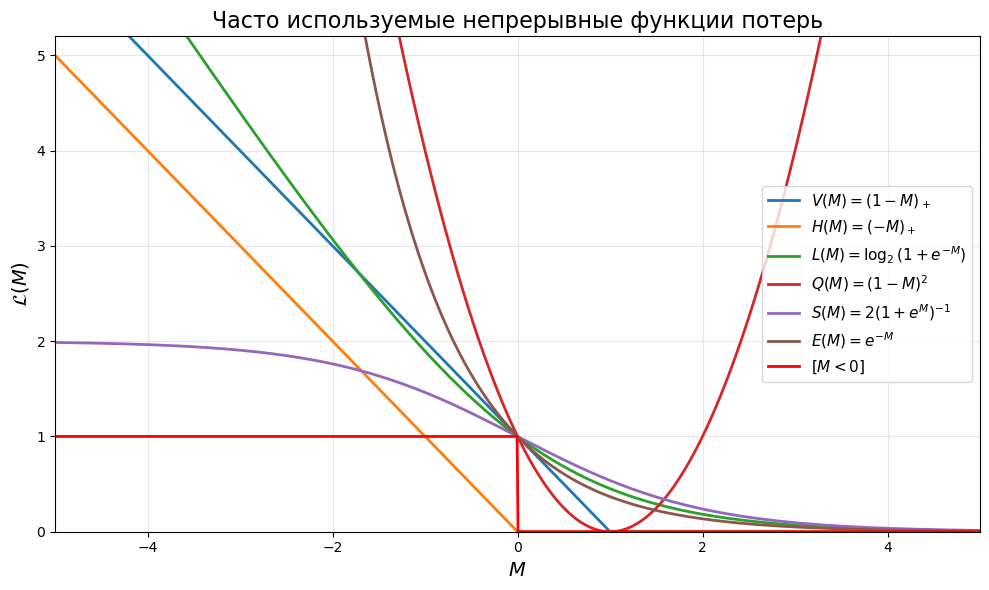

In [14]:
import numpy as np
import matplotlib.pyplot as plt

M = np.linspace(-5, 5, 1000)

V = np.maximum(1 - M, 0)                 # hinge loss
H = np.maximum(-M, 0)                    # Hebb-like
L = np.log2(1 + np.exp(-M))              # logistic loss
Q = (1 - M) ** 2                         # quadratic loss
S = 2 / (1 + np.exp(M))                  # sigmoid loss
E = np.exp(-M)                           # exponential loss
T = (M < 0).astype(float)                # threshold loss [M < 0]

plt.figure(figsize=(10, 6))

plt.plot(M, V, label=r'$V(M)=(1-M)_+$', linewidth=2)
plt.plot(M, H, label=r'$H(M)=(-M)_+$', linewidth=2)
plt.plot(M, L, label=r'$L(M)=\log_2(1+e^{-M})$', linewidth=2)
plt.plot(M, Q, label=r'$Q(M)=(1-M)^2$', linewidth=2)
plt.plot(M, S, label=r'$S(M)=2(1+e^M)^{-1}$', linewidth=2)
plt.plot(M, E, label=r'$E(M)=e^{-M}$', linewidth=2)
plt.plot(M, T, label=r'$[M<0]$', linewidth=2, color='red')

plt.xlim(-5, 5)
plt.ylim(0, 5.2)
plt.grid(True, alpha=0.3)
plt.xlabel(r'$M$', fontsize=14)
plt.ylabel(r'$\mathcal{L}(M)$', fontsize=14)
plt.title('Часто используемые непрерывные функции потерь', fontsize=16)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

## Линейный классификатор — математическая модель нейрона

Линейная модель нейрона МакКаллока–Питтса [1943]:

$$
a(x, w) = \sigma(\langle w, x \rangle) =
\sigma\left(\sum_{j=1}^{n} w_j f_j(x) - w_0\right)
$$

- $\sigma(z)$ — функция активации (например, $\operatorname{sign}$)  
- $w_j$ — весовые коэффициенты синаптических связей  
- $w_0$ — порог активации  

$$
w, x \in \mathbb{R}^{n+1}, \quad \text{если ввести константный признак } f_0(x) \equiv -1
$$

![](img/img08.png)